Матрица внимания (кто на кого смотрит):
[[0.13127398 0.81199505 0.05673096]
 [0.10655384 0.04755135 0.84589481]
 [0.15786301 0.76584077 0.07629622]]

Значения дверцы (gate) для каждого слова:
  Кошка: 0.244
  ест: 0.489
  рыбу: 0.273
  (1.000 = полностью открыта, 0.000 = полностью закрыта)

Выход ОБЫЧНОГО Self-Attention (ДО дверцы):
[[-0.55994464 -0.28229759 -0.59301454  1.48410046]
 [-0.09798448 -0.89676339  0.54453172 -0.90459491]
 [-0.54696128 -0.28657974 -0.5797537   1.38471321]]

Выход GATED Attention (ПОСЛЕ дверцы):
[[-0.13650065 -0.06881717 -0.14456228  0.36178699]
 [-0.04791446 -0.4385177   0.26627625 -0.44234731]
 [-0.14913687 -0.07814009 -0.15807819  0.377562  ]]


C:\Users\Acer\AppData\Local\Temp\ipykernel_11868\2790693444.py:239: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(words, rotation=45)


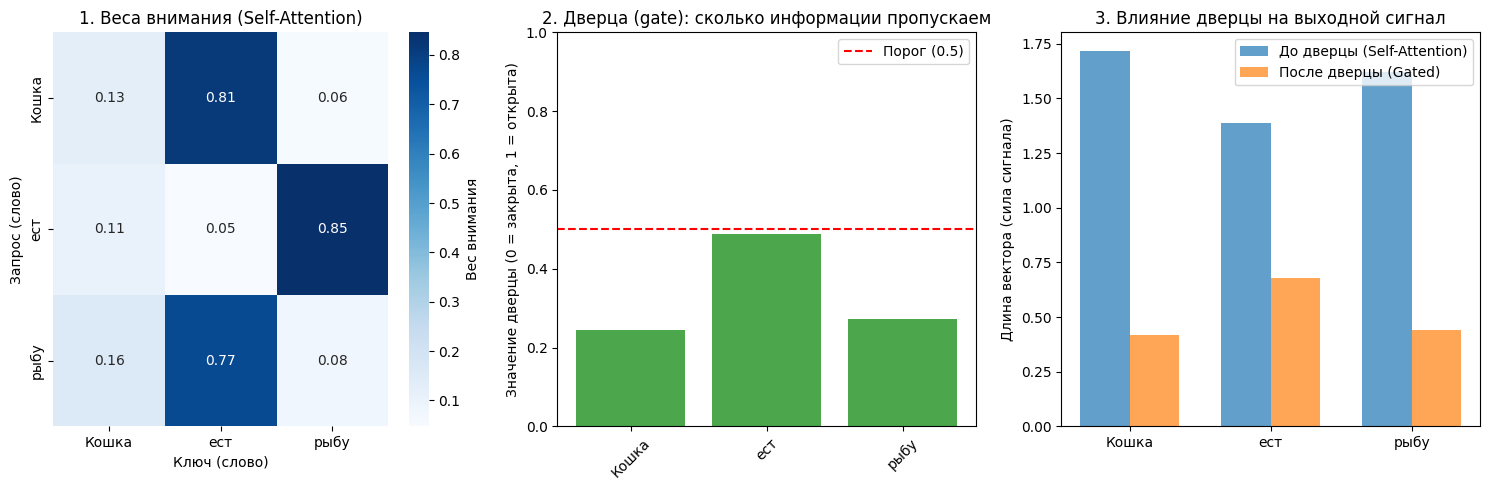


ИНТЕРПРЕТАЦИЯ:
--------------------------------------------------
График 1 показывает, как слова связаны по смыслу.
График 2 показывает дверцу: высокий столбик = слово влияет на ответ.
График 3 сравнивает выход ДО и ПОСЛЕ применения дверцы.


In [ ]:
import numpy as np          # библиотека для работы с массивами и матрицами
import matplotlib.pyplot as plt  # библиотека для построения графиков
import seaborn as sns       # библиотека для красивых тепловых карт (поверх matplotlib)

def softmax(x, axis=-1):
    """
    Функция Softmax: превращает вектор чисел в вероятности (сумма = 1)
    
    Аргументы:
        x — входной массив чисел
        axis — по какой оси суммировать (-1 означает последнюю ось)
    
    Возвращает:
        массив вероятностей, где все значения >0 и в сумме дают 1
    """
    # Вычитаем максимум для численной стабильности (чтобы exp не переполнялся)
    # keepdims=True сохраняет размерность массива (чтобы можно было вычитать)
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    # Делим каждое exp на сумму всех exp по указанной оси
    return e_x / np.sum(e_x, axis=axis, keepdims=True)


def sigmoid(x):
    """
    Сигмоида — сжимает любое число в интервал (0, 1)
    
    Формула: σ(x) = 1 / (1 + e^{-x})
    
    Применение: превращает "сырые" выходы нейронов в "вероятности" или "коэффициенты"
    """
    return 1 / (1 + np.exp(-x))


def gated_attention(Q, K, V):
    """
    Реализует механизм Gated Self-Attention
    
    Входные матрицы:
        Q (Query) — запросы: что мы ищем
        K (Key)   — ключи: с чем сравниваем запросы
        V (Value) — значения: что мы извлекаем при совпадении
    
    Размерности: все матрицы имеют форму (количество_слов, размерность_вектора)
    
    Выход:
        output — результат после применения дверцы (Gated Attention)
        attention_out — результат ДО применения дверцы (обычный Self-Attention)
        weights — матрица весов внимания (кто на кого смотрит)
        gate_values — значения дверцы для каждого слова
    """
    
    # Получаем размерность вектора (d_k) — это количество признаков у каждого слова
    # Q.shape возвращает (количество_слов, размерность)
    # Q.shape[-1] берёт последний элемент — размерность
    d_k = Q.shape[-1]
    
    # Шаг 1.1: Вычисляем "сырые" оценки внимания (scores)
    # Q @ K.T — матричное умножение: (3×4) @ (4×3) = (3×3)
    # Каждый элемент [i, j] показывает, насколько слово i похоже на слово j
    # Делим на √d_k для нормализации (чтобы значения не становились слишком большими)
    scores = Q @ K.T / np.sqrt(d_k)
    
    # Шаг 1.2: Применяем Softmax, чтобы превратить оценки в вероятности
    # Теперь каждая строка матрицы weights суммируется в 1
    # weights[i, j] — насколько слово i "внимательно" к слову j
    weights = softmax(scores, axis=-1)
    
    # Шаг 1.3: Умножаем веса внимания на значения V
    # Результат — взвешенная сумма значений V
    # attention_out[i] — новое представление слова i с учётом контекста всех слов
    attention_out = weights @ V
    
    
    # В РЕАЛЬНОЙ НЕЙРОСЕТИ здесь был бы отдельный обучаемый слой.
    # В нашей демонстрации для простоты используем среднее по Q.
    # np.mean(Q, axis=1) — усредняем все 4 признака каждого слова в одно число
    # keepdims=True сохраняет размерность: из (3,4) получаем (3,1)
    gate_raw = np.mean(Q, axis=1, keepdims=True)
    
    # Применяем сигмоиду, чтобы сжать числа в интервал (0, 1)
    # Теперь gate_values — это числа от 0 до 1 для каждого слова
    # 1 = полностью открыта (пропускаем всё), 0 = полностью закрыта (пропускаем 0)
    gate_values = sigmoid(gate_raw)
    
    
    # Умножаем выход внимания на дверцу ПОЭЛЕМЕНТНО (операция broadcasting)
    # Если gate для слова = 0.5, все 4 числа в его векторе уменьшатся в 2 раза
    output = attention_out * gate_values
    
    # Возвращаем все результаты, которые могут понадобиться для анализа
    return output, attention_out, weights, gate_values


# Фиксируем "зерно" генератора случайных чисел
# Это нужно, чтобы при каждом запуске кода получались ОДИНАКОВЫЕ случайные числа
# Без этого при каждом запуске результаты были бы разными
np.random.seed(42)

# Задаём параметры: 3 слова, каждое описывается вектором из 4 чисел
seq_len = 3   # количество слов в предложении
d_k = 4       # размерность вектора каждого слова

# Список слов — только для подписей на графиках, вычисления на них не влияют
words = ['Кошка', 'ест', 'рыбу']

# Создаём случайные эмбеддинги для Q, K, V
# randn() генерирует числа из нормального распределения (среднее=0, дисперсия=1)
# Каждая матрица имеет размер (3, 4)
Q = np.random.randn(seq_len, d_k)   # матрица запросов
K = np.random.randn(seq_len, d_k)   # матрица ключей
V = np.random.randn(seq_len, d_k)   # матрица значений

# По умолчанию все связи случайны. Мы "руками" настраиваем нужные нам связи,
# чтобы модель поняла смысл предложения "Кошка ест рыбу".

# Связь 1: "Кошка" (слово с индексом 0) должна смотреть на "ест" (слово 1)
# Делаем запрос "Кошки" (Q[0]) похожим на ключ "ест" (K[1])
# Умножаем на 1.5, чтобы связь была сильной (но не абсолютной)
Q[0] = K[1] * 1.5   # Кошка → ест

# Связь 2: "ест" (слово 1) должно смотреть на "рыбу" (слово 2)
# Запрос "ест" делаем похожим на ключ "рыбу"
Q[1] = K[2] * 1.5   # ест → рыбу

# Связь 3: "рыбу" (слово 2) смотрит на "ест" (слово 1)
# Запрос "рыбу" делаем похожим на ключ "ест"
Q[2] = K[1] * 1.3   # рыбу → ест

# Вызываем нашу функцию и получаем 4 результата
# Порядок возврата соответствует порядку в return функции
output, attention_out, attn_weights, gate_vals = gated_attention(Q, K, V)

# Выводим матрицу внимания (кто на кого смотрит)
print("Матрица внимания (кто на кого смотрит):")
print(attn_weights)

# Выводим значения дверцы для каждого слова
print("\nЗначения дверцы (gate) для каждого слова:")
for i, word in enumerate(words):                     # перебираем слова по индексу
    # gate_vals[i][0] — берём первое (и единственное) значение для i-го слова
    print(f"  {word}: {gate_vals[i][0]:.3f}")        # :.3f — выводим с 3 знаками после запятой
print("  (1.000 = полностью открыта, 0.000 = полностью закрыта)")

# Выводим выход обычного Self-Attention (до применения дверцы)
print("\nВыход ОБЫЧНОГО Self-Attention (ДО дверцы):")
print(attention_out)

# Выводим выход Gated Attention (после применения дверцы)
print("\nВыход GATED Attention (ПОСЛЕ дверцы):")
print(output)


# Создаём фигуру с 3 графиками в один ряд (1 строка, 3 колонки)
# fig — объект фигуры, axes — массив из 3 объектов осей (по одному на график)
# figsize=(15, 5) — размер фигуры: 15 дюймов в ширину, 5 в высоту
fig, axes = plt.subplots(1, 3, figsize=(15, 5))


# sns.heatmap — рисует тепловую карту (цветами показывает значения)
sns.heatmap(
    attn_weights,                     # данные для отображения
    annot=True,                       # показывать числовые значения внутри клеток
    fmt='.2f',                        # формат чисел: 2 знака после запятой
    xticklabels=words,                # подписи по оси X (названия слов)
    yticklabels=words,                # подписи по оси Y (названия слов)
    cmap='Blues',                     # цветовая схема (оттенки синего)
    ax=axes[0],                       # рисовать на первом графике (индекс 0)
    cbar_kws={'label': 'Вес внимания'}  # подпись для цветовой шкалы
)
axes[0].set_title('1. Веса внимания (Self-Attention)')  # заголовок
axes[0].set_ylabel('Запрос (слово)')   # подпись оси Y
axes[0].set_xlabel('Ключ (слово)')     # подпись оси X


# .bar() рисует столбчатую диаграмму
# gate_vals.flatten() — превращает матрицу (3,1) в плоский массив из 3 элементов
bars = axes[1].bar(words, gate_vals.flatten(), color='green', alpha=0.7)
# alpha=0.7 — прозрачность 70% (немного прозрачные столбики)

# Рисуем горизонтальную линию на уровне y=0.5 (порог)
# color='red' — красный цвет, linestyle='--' — пунктирная линия
axes[1].axhline(y=0.5, color='red', linestyle='--', label='Порог (0.5)')

# Устанавливаем границы оси Y от 0 до 1 (потому что сигмоида даёт значения в этом диапазоне)
axes[1].set_ylim(0, 1)

axes[1].set_title('2. Дверца (gate): сколько информации пропускаем')
axes[1].set_ylabel('Значение дверцы (0 = закрыта, 1 = открыта)')
axes[1].legend()                       # показываем легенду (объяснение линий)

# Поворачиваем подписи на оси X на 45 градусов, чтобы они не налезали друг на друга
axes[1].set_xticklabels(words, rotation=45)


# Вычисляем норму (длину) каждого выходного вектора
# np.linalg.norm — евклидова норма: sqrt(x₁² + x₂² + ... + xₙ²)
# axis=1 — вычисляем норму по строкам (отдельно для каждого слова)
input_norms = np.linalg.norm(attention_out, axis=1)   # ДО дверцы
output_norms = np.linalg.norm(output, axis=1)         # ПОСЛЕ дверцы

# x — координаты столбцов: [0, 1, 2] (по индексам слов)
x = np.arange(len(words))

# width — ширина одного столбца
width = 0.35

# Рисуем первую группу столбцов (ДО дверцы)
# x - width/2 — сдвигаем столбцы влево, чтобы они не сливались со второй группой
axes[2].bar(x - width/2, input_norms, width, label='До дверцы (Self-Attention)', alpha=0.7)

# Рисуем вторую группу столбцов (ПОСЛЕ дверцы)
# x + width/2 — сдвигаем столбцы вправо
axes[2].bar(x + width/2, output_norms, width, label='После дверцы (Gated)', alpha=0.7)

# Устанавливаем подписи по оси X (названия слов)
axes[2].set_xticks(x)                # позиции, куда ставить подписи
axes[2].set_xticklabels(words)       # сами подписи

axes[2].set_title('3. Влияние дверцы на выходной сигнал')
axes[2].set_ylabel('Длина вектора (сила сигнала)')
axes[2].legend()                     # показываем легенду

# tight_layout() автоматически настраивает отступы, чтобы графики не налезали друг на друга
plt.tight_layout()

# show() отображает окно с графиками на экране
plt.show()


print("\nИНТЕРПРЕТАЦИЯ:")
print("-" * 50)   # печатает 50 дефисов (разделительная линия)
print("График 1 показывает, как слова связаны по смыслу.")
print("График 2 показывает дверцу: высокий столбик = слово влияет на ответ.")
print("График 3 сравнивает выход ДО и ПОСЛЕ применения дверцы.")